<a href="https://colab.research.google.com/github/leticiasdrummond/Modelos-Base/blob/codex%2Fmodel-analysis-from-attachment/criar_notebook_para_executar_no_colab_do_google_b_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



---



Excelente escolha! Migrar esse modelo para o Google Colab é o caminho ideal para visualizar os resultados e iterar rapidamente.

Para que o código funcione perfeitamente no ambiente do Colab, fiz **duas adaptações importantes**:

1. **Instalação do Gurobi:** Substituí o arquivo local (`.whl`) pelo comando oficial do repositório Python (`!pip install gurobipy`). O Gurobi possui uma licença gratuita embutida para modelos pequenos (como este de 24 períodos), então ele rodará perfeitamente.
2. **Visualização Gráfica:** Adicionei a biblioteca `matplotlib` ao final do código para gerar um gráfico automático do despacho de energia e do nível da bateria. Isso é fundamental para a análise de dados no Colab.

Abaixo está a estrutura exata que você deve copiar e colar no seu Google Colab, dividida entre **Células de Texto (Markdown)** e **Células de Código (Python)**.

---

### 📝 Célula de Texto 1 (Markdown)

*Copie e cole o texto abaixo em uma célula de texto para ter a documentação matemática salva no seu notebook.*

```markdown
# Dimensionamento e Despacho Ótimo: Eletroposto + PV + BESS

Este notebook implementa um modelo de otimização para minimizar os custos operacionais de um eletroposto integrado com geração solar (PV) e sistema de armazenamento em baterias (BESS).

## 🎯 Objetivo
Minimizar o custo total de operação comprando energia da rede apenas quando necessário ou barato:
$$\min \sum_{t} c_t^{grid} \cdot P_t^{grid}$$

## 🔋 Variáveis de Decisão (para cada período $t$)
* $P_t^{grid}$: energia comprada da rede
* $P_t^{ch}$: potência de carga da bateria
* $P_t^{dis}$: potência de descarga da bateria
* $SOC_t$: estado de carga da bateria (State of Charge)
* $P_t^{pv}$: energia utilizada diretamente do painel solar
* $u_t$: variável binária (0 ou 1) para evitar carga e descarga simultâneas

## 📏 Restrições Principais
1. **Balanço de Energia:**
$$P_t^{grid} + P_t^{pv} + P_t^{dis} = D_t + P_t^{ch}$$

2. **Dinâmica da Bateria:**
$$SOC_t = SOC_{t-1} + \eta_{ch} P_t^{ch} - \frac{1}{\eta_{dis}} P_t^{dis}$$

```

---

### 💻 Célula de Código 1 (Instalação e Setup)

*Crie uma célula de código e execute esta etapa primeiro.*

In [ ]:
# Instalação do Gurobi (a licença restrita padrão resolve modelos pequenos)
!pip install gurobipy matplotlib numpy

import gurobipy as gp
from gurobipy import GRB
import numpy as np
import matplotlib.pyplot as plt

---

### 💻 Célula de Código 2 (Modelagem, Otimização e Gráficos)

*Esta é a célula principal onde a "mágica" acontece.*

In [ ]:
# ==========================================
# 1. PARÂMETROS E DADOS DE ENTRADA
# ==========================================
T = 24 # Horizonte de tempo (24 horas)

# Dados simulados (semente fixa para reprodutibilidade)
np.random.seed(42)
D = np.random.uniform(20, 50, T)                           # Demanda do eletroposto
PV = np.maximum(0, 40 * np.sin(np.linspace(0, np.pi, T)))  # Curva de geração PV (Pico no meio do dia)
c_grid = np.concatenate([np.linspace(0.2, 0.2, 8),         # Madrugada (barato)
                         np.linspace(0.3, 0.5, 10),        # Dia (médio/alto)
                         np.linspace(0.6, 0.6, 4),         # Ponta/Fim de tarde (muito caro)
                         np.linspace(0.3, 0.2, 2)])        # Noite (caindo)

# Parâmetros do BESS (Battery Energy Storage System)
SOC_max = 100
Pch_max = 30
Pdis_max = 30
eta_ch = 0.95
eta_dis = 0.95

# ==========================================
# 2. CONSTRUÇÃO DO MODELO
# ==========================================
m = gp.Model("PV_BESS_Charging_Station")

# Variáveis
P_grid = m.addVars(T, lb=0, name="P_grid")
P_pv = m.addVars(T, lb=0, name="P_pv")
P_ch = m.addVars(T, lb=0, name="P_ch")
P_dis = m.addVars(T, lb=0, name="P_dis")
SOC = m.addVars(T, lb=0, ub=SOC_max, name="SOC")
u = m.addVars(T, vtype=GRB.BINARY, name="u") # 1 se carregando, 0 se descarregando/parada

# Função Objetivo: Minimizar custo da rede
m.setObjective(gp.quicksum(c_grid[t] * P_grid[t] for t in range(T)), GRB.MINIMIZE)

# Restrições
for t in range(T):
    # 1. Balanço de energia
    m.addConstr(P_grid[t] + P_pv[t] + P_dis[t] == D[t] + P_ch[t], name=f"Balanço_{t}")

    # 2. Limite do PV (não posso usar mais do que o sol está gerando)
    m.addConstr(P_pv[t] <= PV[t], name=f"PV_max_{t}")

    # 3. Limites de carga e descarga (Complementaridade com variável binária)
    m.addConstr(P_ch[t] <= Pch_max * u[t], name=f"Ch_limit_{t}")
    m.addConstr(P_dis[t] <= Pdis_max * (1 - u[t]), name=f"Dis_limit_{t}")

    # 4. Dinâmica do SOC (Estado da Bateria)
    if t == 0:
        # Condição inicial: começa com 50% de bateria
        m.addConstr(SOC[t] == 50 + eta_ch * P_ch[t] - (1 / eta_dis) * P_dis[t], name=f"SOC_dyn_{t}")
    else:
        m.addConstr(SOC[t] == SOC[t-1] + eta_ch * P_ch[t] - (1 / eta_dis) * P_dis[t], name=f"SOC_dyn_{t}")

# ==========================================
# 3. OTIMIZAÇÃO E EXTRAÇÃO DE RESULTADOS
# ==========================================
m.optimize()

if m.status == GRB.OPTIMAL:
    print(f"\n✅ Otimização concluída! Custo Total Ótimo: R$ {m.objVal:.2f}")

    # Extraindo valores para listas (facilita o plot)
    res_grid = [P_grid[t].x for t in range(T)]
    res_pv = [P_pv[t].x for t in range(T)]
    res_dis = [P_dis[t].x for t in range(T)]
    res_ch = [P_ch[t].x for t in range(T)]
    res_soc = [SOC[t].x for t in range(T)]

    # ==========================================
    # 4. VISUALIZAÇÃO GRÁFICA (Dashboard)
    # ==========================================
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Eixo 1: Potências (Barras e Linhas)
    ax1.bar(range(T), D, color='lightgray', label='Demanda (D)', alpha=0.5)
    ax1.plot(range(T), res_grid, color='red', marker='o', label='Uso da Rede (Grid)')
    ax1.plot(range(T), res_pv, color='orange', marker='s', label='Uso do PV')
    ax1.bar(range(T), res_dis, color='green', label='Descarga Bateria', alpha=0.7)
    ax1.bar(range(T), [-val for val in res_ch], color='blue', label='Carga Bateria', alpha=0.7)

    ax1.set_xlabel('Hora do Dia (t)')
    ax1.set_ylabel('Potência (kW)')
    ax1.set_title('Despacho Ótimo: Eletroposto + PV + BESS')
    ax1.axhline(0, color='black', linewidth=1)
    ax1.legend(loc='upper left')

    # Eixo 2: SOC da Bateria (Linha tracejada no fundo)
    ax2 = ax1.twinx()
    ax2.plot(range(T), res_soc, color='purple', linestyle='--', linewidth=2, label='SOC da Bateria')
    ax2.set_ylabel('Energia Armazenada (kWh)', color='purple')
    ax2.tick_params(axis='y', labelcolor='purple')
    ax2.set_ylim(0, SOC_max * 1.1)
    ax2.legend(loc='upper right')

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

else:
    print("O modelo não encontrou uma solução ótima.")

---

### 📝 Célula de Texto 2 (Interpretação)

*Última célula de texto para registrar seus aprendizados no final do notebook.*

```markdown
## 💡 Análise dos Resultados

Observando o gráfico gerado, podemos notar os comportamentos clássicos de otimização de energia:
1. **Prioridade Solar:** Toda a geração fotovoltaica disponível é aproveitada, pois possui custo zero.
2. **Arbitragem de Energia (Load Shifting):** A bateria carrega durante a madrugada (quando $c_t^{grid}$ é barato) e durante o pico solar.
3. **Peak Shaving:** Nos momentos em que a tarifa da rede atinge seu valor máximo (horário de ponta), a bateria é descarregada para suprir a demanda dos veículos, evitando a compra de energia cara.

```

---

**Gostaria que o próximo passo seja integrar perfis reais de Tarifa Branca do Brasil (ex: dados da CPFL ou Enel) ou prefere adicionar a equação de CAPEX para que o modelo calcule o tamanho ideal da bateria sozinho?**



---

❎gerad como resposta do gemini
prompr:


criar notebook para executar no colab do google baseado em exemplos :Perfeito — você está indo direto para um nível mais avançado de modelagem com sistemas energéticos (PV + BESS + eletroposto). Vou estruturar isso como um exemplo completo estilo “modeling2 / exercise_set2”, incluindo teoria + modelo + código em Gurobi.
⚙️ Instalação
Execute no Code Interpreter:

!pip install /mnt/data/gurobipy-13.0.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl
🔢 Problem definition
📌 Contexto: Dimensionamento e despacho ótimo de PV + BESS para eletroposto
Queremos modelar:

Um eletroposto com demanda de carregamento ao longo do tempo
Geração fotovoltaica (PV) variável
Um sistema de bateria (BESS)
Possibilidade de compra da rede
🎯 Objetivo
Minimizar o custo total de operação:
[
\min \sum_{t} c_t^{grid} \cdot P_t^{grid}
]
🔋 Variáveis de decisão
Para cada período ( t ):

( P_t^{grid} ): energia comprada da rede
( P_t^{ch} ): carga da bateria
( P_t^{dis} ): descarga da bateria
( SOC_t ): estado de carga da bateria
( P_t^{pv} ): energia utilizada do PV
📊 Parâmetros
( D_t ): demanda do eletroposto
( PV_t ): geração disponível do PV
( c_t^{grid} ): custo da energia da rede
( \eta_{ch}, \eta_{dis} ): eficiências
( SOC^{max} ): capacidade da bateria
( P^{ch,max}, P^{dis,max} ): limites de potência
📏 Restrições
1. Balanço de energia
[
P_t^{grid} + P_t^{pv} + P_t^{dis} = D_t + P_t^{ch}
]
2. Limite do PV
[
0 \leq P_t^{pv} \leq PV_t
]
3. Dinâmica da bateria
[
SOC_t = SOC_{t-1} + \eta_{ch} P_t^{ch} - \frac{1}{\eta_{dis}} P_t^{dis}
]
4. Limites do SOC
[
0 \leq SOC_t \leq SOC^{max}
]
5. Limites de carga/descarga
[
0 \leq P_t^{ch} \leq P^{ch,max}
]
[
0 \leq P_t^{dis} \leq P^{dis,max}
]
6. (Opcional) Não carregar e descarregar simultaneamente
Variável binária:
[
u_t \in {0,1}
]
[
P_t^{ch} \leq u_t \cdot P^{ch,max}
]
[
P_t^{dis} \leq (1-u_t) \cdot P^{dis,max}
]
🐍 Build and solve model
# Install Gurobi
!pip install /mnt/data/gurobipy-13.0.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl

import gurobipy as gp
from gurobipy import GRB
import numpy as np

# Time horizon
T = 24

# Example data
np.random.seed(0)
D = np.random.uniform(20, 50, T)           # demand
PV = np.maximum(0, 30*np.sin(np.linspace(0, np.pi, T)))  # PV curve
c_grid = np.linspace(0.2, 0.5, T)         # price variation

# Battery parameters
SOC_max = 100
Pch_max = 30
Pdis_max = 30
eta_ch = 0.95
eta_dis = 0.95

# Model
m = gp.Model("PV_BESS_Charging_Station")

# Variables
P_grid = m.addVars(T, lb=0)
P_pv = m.addVars(T, lb=0)
P_ch = m.addVars(T, lb=0)
P_dis = m.addVars(T, lb=0)
SOC = m.addVars(T, lb=0, ub=SOC_max)
u = m.addVars(T, vtype=GRB.BINARY)

# Objective
m.setObjective(gp.quicksum(c_grid[t]*P_grid[t] for t in range(T)), GRB.MINIMIZE)

# Constraints
for t in range(T):
    # Energy balance
    m.addConstr(P_grid[t] + P_pv[t] + P_dis[t] == D[t] + P_ch[t])
    
    # PV limit
    m.addConstr(P_pv[t] <= PV[t])
    
    # Charge/discharge limits
    m.addConstr(P_ch[t] <= Pch_max * u[t])
    m.addConstr(P_dis[t] <= Pdis_max * (1 - u[t]))
    
    if t == 0:
        m.addConstr(SOC[t] == 50 + eta_ch*P_ch[t] - (1/eta_dis)*P_dis[t])
    else:
        m.addConstr(SOC[t] == SOC[t-1] + eta_ch*P_ch[t] - (1/eta_dis)*P_dis[t])

# Optimize
m.optimize()

# Results
print("\nOptimal cost:", m.objVal)

for t in range(T):
    print(f"t={t}: Grid={P_grid[t].x:.2f}, PV={P_pv[t].x:.2f}, SOC={SOC[t].x:.2f}")
👩‍🏫 Results
📊 Interpretação típica
O modelo aprende automaticamente:

Usar PV primeiro (custo zero)
Armazenar energia quando há excesso
Descarregar bateria quando energia está cara
Minimizar uso da rede em horários caros
⚡ Insights para dimensionamento (eletroposto)
Esse modelo é base para:

1. Dimensionamento do BESS
Testar diferentes ( SOC^{max} )
Avaliar redução de custo
Encontrar ponto ótimo CAPEX vs OPEX
2. Dimensionamento do PV
Aumentar ( PV_t )
Ver impacto na redução da rede
3. Estratégia de operação
Arbitragem de energia
Peak shaving
Load shifting
🔁 Extensões estilo modeling2 / exercise_set2
Você pode evoluir para:

✔ Investimento (modelo bilevel simplificado)
Adicionar variável:
[
SOC^{max} \rightarrow variável de decisão
]
✔ Tarifas reais
Tarifa branca
Demanda contratada
✔ Múltiplos carregadores EV
Filas
Perfis de carga
✔ Degradação da bateria
Custo por ciclo:
[
c^{deg} \cdot P_t^{dis}
]
📌 Versão do Gurobi
gurobipy 13.0.0
🔚 Conclusão
Esse exemplo já é equivalente a um “optimize_power_schedule + despacho de bateria + PV+BESS” completo, e serve como base direta para:

Pesquisa acadêmica
Planejamento de eletropostos
Estudos de viabilidade
Se quiser, posso te levar para o próximo nível:

incluir CAPEX e fazer dimensionamento ótimo automático
ou montar um caso real com dados do Brasil ⚡
For more guidance, see the documentation for this Custom GPT

O Gemini disse
Excelente escolha! Migrar esse modelo para o Google Colab é o caminho ideal para visualizar os resultados e iterar rapidamente.

Para que o código funcione perfeitamente no ambiente do Colab, fiz duas adaptações importantes:

Instalação do Gurobi: Substituí o arquivo local (.whl) pelo comando oficial do repositório Python (!pip install gurobipy). O Gurobi possui uma licença gratuita embutida para modelos pequenos (como este de 24 períodos), então ele rodará perfeitamente.

Visualização Gráfica: Adicionei a biblioteca matplotlib ao final do código para gerar um gráfico automático do despacho de energia e do nível da bateria. Isso é fundamental para a análise de dados no Colab.

Abaixo está a estrutura exata que você deve copiar e colar no seu Google Colab, dividida entre Células de Texto (Markdown) e Células de Código (Python).

📝 Célula de Texto 1 (Markdown)
Copie e cole o texto abaixo em uma célula de texto para ter a documentação matemática salva no seu notebook.

# **EXEMPLOS GUROBI**

## **1. Optimizing a power generation schedule**


The electricity grid powers nearly every aspect of modern life — be it charging a phone, powering a factory, or mining Bitcoin.
Energy sector decision-makers must ensure a smooth and adequate power supply that caters to the growing power needs of modern life.
After all, with great power comes great responsibility.

In [ ]:
from PIL import Image
import requests
from io import BytesIO

print('Nuclear power plants. Source: Daniel Prudek / Shutterstock).')
img = Image.open(BytesIO(requests.get('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/image_powerplant.png?raw=true').content))
img
# Image('image_powerplant.png')

Managing the supply and demand of electricity can be a complex and challenging task. Suppose that we are in charge of generating power for the U.S. State of Georgia. Assume that we know the set of all available power plants and the demand for power for each hour of a day. Can we create a schedule to decide how much power each plant should generate, and when to switch the plants "on" and "off"? How can we do so while minimizing the overall costs?

In this notebook, we model this decision-making problem using **mathematical optimization**. The first part of the notebook describes the datasets used. We use real data from the State of Georgia with a population of 10.8 million people. The data includes historical demand for power as well as specific information about the power plants.

The second part of the notebook introduces the three components of a mathematical optimization model: the objective function to be optimized, the decision variables, and the constraints. In our power generation problem, the **objective** is to minimize the overall costs. The **decision variables** model the power generation schedule. The **constraints** capture basic requirements such as ensuring that the power supply meets the demand, as well as practical limitations such as the minimum and maximum production levels for each power plant. By finding the optimally cost-efficient schedule, this model helps power plant operators get the best output from their facilities while minimizing the overall costs.


Let's get started.

## The data

First, let us load the following packages needed to process and visualize the data.

In [11]:
%pip install networkx seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Historical power demand data

First, read the demand data.
The 'demand.csv' file contains the historical demand for power in the State of Georgia from 2004 to 2013.
This data is available for each hour of the 31 days of two months --- summer month (July) and a winter month (January).

For the rest of this notebook, we will pick a date, say July 1st, 2011.

We store the demand as a dictionary indexed by each hour (between 1 and 24) and valued by the amount of power needed.

In [12]:
df_load_curves = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/demand.csv?raw=true')
# df_load_curves = pd.read_csv('demand.csv')

# select the demand for the chosen day (July 1st, 2011)
df_subset = df_load_curves[(df_load_curves['YEAR']==2011)&(df_load_curves['MONTH']==7)&(df_load_curves['DAY']==1)]

# store the demand to a dicionary
d = df_subset.set_index(['HOUR']).LOAD.to_dict()

H = set(d.keys()) # set of hours in a day (1 through 24)

We can visualize the power usage in Georgia on July 1st, 2011.

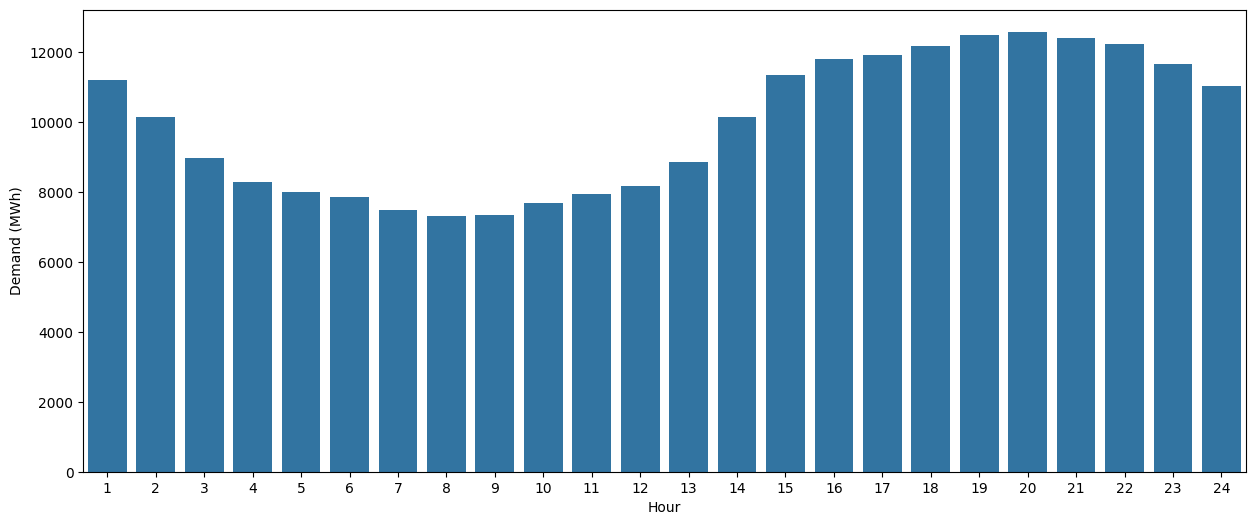

In [13]:
fig, ax = plt.subplots(figsize=(15,6))
demand_plot = sns.barplot(x=list(range(1,25)), y=[d[h] for h in range(1,25)])
demand_plot.set_xticklabels(demand_plot.get_xticklabels());
demand_plot.set(xlabel='Hour', ylabel='Demand (MWh)');
plt.show()

The power utilization is higher in the evenings than in the mornings.

### Power plant data

Next, let us load information about the power plants.

The real dataset is **large**, with 99 power plants. Solving the optimization problem using the large dataset requires a full Gurobi license.
If you are an academic (student or faculty), you can request a free Gurobi license [here](https://www.gurobi.com/academia/academic-program-and-licenses/).
To use the Gurobipy package without a license, this notebook uses a simplified smaller dataset with **ten groups** of power plants.
To test the model with the full data, simply replace 'small_plant_data' with 'large_plant_data' in the rest of the code.

Power plants come in different types based on the type of fuel they consume.
From our dataset, there are **six types** of power plants: coal, nuclear, oil, gas hydro, and biomass.
In the small data used in this notebook, we have ten power plants - namely two nuclear plants (Edwin I Hatch and Vogtle) and three coal plants (Bowen, Jack McDonough and Scherer), with rest of the coal plants grouped into one mega-plant named 'OTHER COAL', and four groups of merged plants for each of the four plant types, named 'BIOMASS', 'GAS', 'HYDRO', and 'OIL'.

The **fuel** used by each power plant is also loaded from the files. This information is necessary to determine some of the fuel-dependent costs.

We now load this data.

In [14]:
df_plant_info = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/plant_capacities.csv?raw=true') # replace "small_plant_data" with "large_plant_data" to use the full dataset
# df_plant_info = pd.read_csv('small_plant_data/plant_capacities.csv')

P = set(df_plant_info['Plant'].unique())                          # set of all power plants

plant_type = df_plant_info.set_index('Plant').PlantType.to_dict() # plant type for each plant

P_N = set([i for i in P if plant_type[i]=='NUCLEAR'])             # set of all nuclear plants

fuel_type = df_plant_info.set_index('Plant').FuelType.to_dict()   # fuel type for each plant


### Plant capacities and limits

The overall goal is to determine the amount of power to generate from each plant. This amount must be within the plant's minimum and maximum production limits (in MWh). See below for a visualization of the maximum production limits for the ten plants.

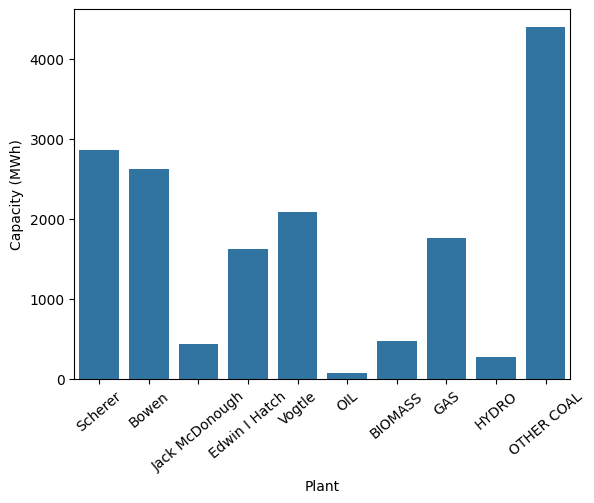

In [15]:
df_plant_info['capacity'] = df_plant_info['Capacity']
c = df_plant_info.set_index('Plant').capacity.to_dict() # generation capacity

capacity_plot = sns.barplot(x=list(c.keys()), y=[c[k] for k in c])
capacity_plot.set_xticklabels(capacity_plot.get_xticklabels(), rotation=40);
capacity_plot.set(xlabel='Plant', ylabel='Capacity (MWh)');
plt.show()

Clearly, coal plants are capable of the highest production capacities, followed by nuclear and hydro plants.

Moreover, if a nuclear power plant is turned "on," it has to generate at least 80% of its maximum capacity. For the rest of the plants, we set this minimum limit to 1%.

In [16]:
m = {i: 0.8 if i in P_N else 0.01 for i in P} # min % generation when on

Additionally, we also have a limit on how much the power generation schedule can **ramp up** or **ramp down** the power generation between successive hours.
This limit ensures that the plants are not forced make drastic changes to their generation schedule.

We set this speed limit to be **20%** for nuclear plants and **25%** for coal plants. In other words, a coal plant cannot be ramped up or ramped down within an hour by more than 25% of its total capacity.
We set the speed limit to be **100%** for all other plants thereby imposing no limit on the speed.

In [17]:
r = {i: 1 if i in ['BIOMASS','GAS','HYDRO','OIL'] else .2 if i in P_N else .25 for i in P}  # ramp up/down speed (plant)

### Costs

Finally, we load the cost data. There are five types of costs: fuel costs, operating costs, start-up and shut-down costs, and health costs.
We have historical yearly average data (for 2004-2011) on these costs based on fuel type.
For the rest of the notebook, we will use the average costs for 2011.

First is the **fuel costs**, which measure the cost of producing *one* MWh of power.
As visualized below, the coal and gas fuel types are the most expensive, while nuclear is the least expensive.

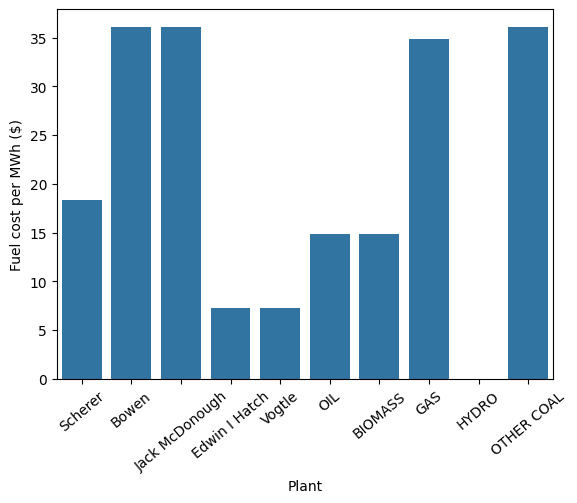

In [18]:
df_fuel_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/fuel_costs.csv?raw=true')
# df_fuel_costs = pd.read_csv('small_plant_data/fuel_costs.csv')

# read the fuel costs and transform it from fuel-type to plant-name
f = {i: df_fuel_costs[df_fuel_costs['year']==2011].T.to_dict()[9][fuel_type[i]] for i in fuel_type} # dictionary of fuel cost for each plant

# plot the fuel costs
fuelcost_plot = sns.barplot(x=list(f.keys()), y=[f[k] for k in f])
fuelcost_plot.set_xticklabels(fuelcost_plot.get_xticklabels(), rotation=40);
fuelcost_plot.set(xlabel='Plant', ylabel='Fuel cost per MWh ($)');
plt.show()

The second is the **operation costs**, which is the cost per hour of keeping a power plant on.

In [19]:
df_oper_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/operating_costs.csv?raw=true')
# df_oper_costs = pd.read_csv('small_plant_data/operating_costs.csv')
o = {i: df_oper_costs[df_oper_costs['year']==2011].T.to_dict()[9][fuel_type[i]] for i in fuel_type} # operating cost/MWh (plant)

The third and fourth are the **startup** and **shutdown costs**, which penalize whenever a plant is started up and shut down. Incorporating these costs in the model ensures a stable power generation schedule.

In [20]:
df_startup_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/startup_costs.csv?raw=true')
# df_startup_costs = pd.read_csv('small_plant_data/startup_costs.csv')
s = {i: df_startup_costs[df_startup_costs['year']==2011].T.to_dict()[9][fuel_type[i]] for i in fuel_type} # operating cost/MWh (plant)

t = s.copy() # assume that the cost of shuting down = starting up

Finally, we load the **health costs**, which capture the health effects of burning too much coal. This data is only available for the three coal plants (Bowen, Jack McDonough and Scherer).


The health costs are aggregated using a variety of environmental factors that depend on the time of the day. As a result, these costs are indexed for each hour. See the visualization below for health costs for the Bowen power plant to observe that the costs are much higher in the evenings than in the mornings.

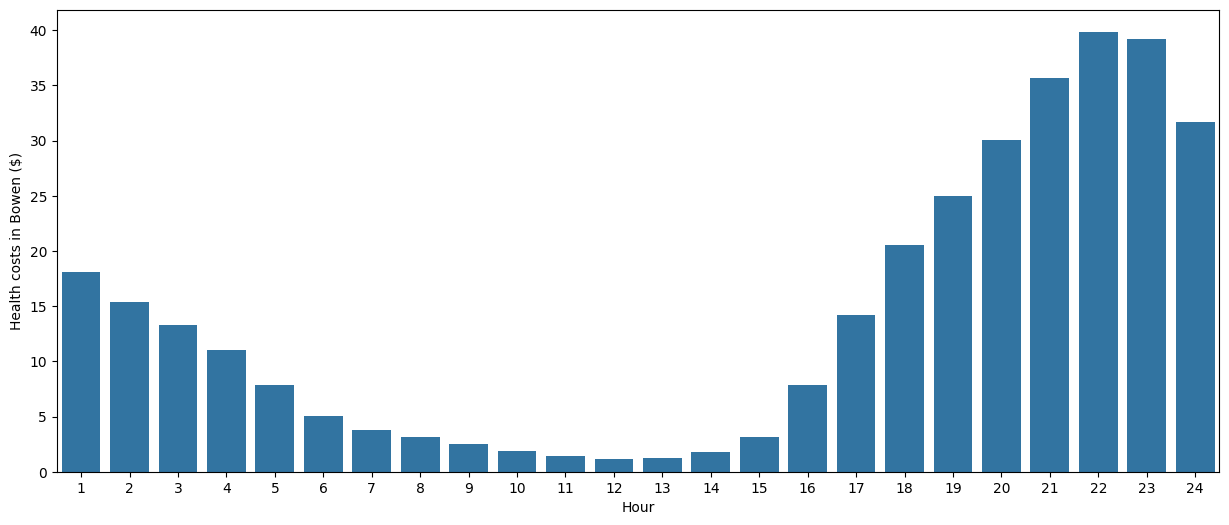

In [21]:
df_health_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/health_costs.csv?raw=true')
# df_health_costs = pd.read_csv('small_plant_data/health_costs.csv')
a = df_health_costs[(df_health_costs['Year']==2007)&(df_health_costs['Day']==1)].set_index(['Plant','Hour']).to_dict()['Cost'] # operating cost/MWh (plant)
a.update({(i,h): 0 for i in P for h in H if i not in ['Bowen','Jack McDonough','Scherer']})

fig, ax = plt.subplots(figsize=(15,6))
healthcost_plot = sns.barplot(x=list(range(1,25)), y=[a['Bowen',h] for h in range(1,25)])
healthcost_plot.set_xticklabels(healthcost_plot.get_xticklabels());
healthcost_plot.set(xlabel='Hour', ylabel='Health costs in Bowen ($)');
plt.show()

## Optimization model

We will now address the decision-making problem.
Using the ten power plants, and knowing their capabilities and limitations, what is the most cost-effective way to generate power from them in order to completely satisfy the energy demand in Georgia?

We can capture these complex considerations in a mathematical optimization model.
An optimization model finds the **best solution** according to an **objective function** such that the solution satisfies a set of **constraints**.
Here, a solution is expressed as a vector of real values or integer values called **decision variables**.
Constraints are a set of equations or inequalities written as a function of the decision variables.

For our power generation problem, the objective is to minimize the overall costs.
The decision variables represent the power generation schedule for each power plant.
The limits and capacities of the power plants are captured using the constraints.

Let us now define the inputs to the model. The subscripts $i$ and $h$ will be used to denote each power plant and hour, respectively.

### Input Parameters
Sets:
- $P\ (P_N)$: set of (nuclear) power plants,
- $H$: set of hours.

Demand, capacity and speed limits:
- $d_h$: power demand for each hour $h$,
- $c_i$: maximum power generation capacity for power plant $i$,
- $m_i$: minimum % power that must be generated from power plant $i$,
- $r_i$: ramp up/ramp down speed for power plant $i$.

Costs:
- $f_i, o_i$: fuel and operating costs for power plant $i$,
- $a_{ih}$: health costs for power plant $i$ in hour $h$,
- $s_i, t_i$: startup and shutdown costs for power plant $i$.

We have already loaded these parameters and have stored each input as a dictionary.

The following code loads the Gurobi python package and initiates the optimization model.

In [22]:
%pip install gurobipy
import gurobipy as gp
from gurobipy import GRB
model = gp.Model("powergeneration")

Having initiated the optimization model, we will now build the model step by step by adding the variables, objective and constraints.

First, we will define the decision variables.
There are several types of variables based on the range of values they can take.
A **continuous** variable can take any real value within lower and upper bounds, whereas a **binary** variable can be either 0 or 1.

Our key decision variable is a continuous variable.
Let $z_{i,h}$ be the amount of power to be generated from power plant $i$ during hour $h$; this has to be *at least* $0$.

We can add this variable to the model using gurobipy's **addVars** function.

In [23]:
z = model.addVars(P, H, name="z", lb=0)             # power generated in each plant for each hour

The rest of the decision variables in our model are binary variables, meaning they act as on/off switches.
Let $u_{i,h}$ be an indicator of whether plant $i$ is *on* during hour $h$.
Further, let $v_{i,h}$ and $w_{i,h}$ be indicators of whether plant $i$ is *started up* or *shut down*, respectively, for hour $h$.
Each of these variables takes the value $1$ if true, or $0$ otherwise.

We now add these binary variables to the model using the **addVars** function.

In [24]:
u = model.addVars(P, H, name="u", vtype=GRB.BINARY) # is the plant on? for each plant and hour

v = model.addVars(P, H, name="v", vtype=GRB.BINARY) # start up the plant? for each plant and hour

w = model.addVars(P, H, name="w", vtype=GRB.BINARY) # shut down the plant? for each plant and hour

print("This model has",len(z)+len(u)+len(v)+len(w),"decision variables.")

model.update()

This model has 960 decision variables.


### Objective: Minimize the total costs

Having defined the variables, we now tell the model what to optimize for.
We want to minimize the overall costs composed of five components - fuel, health, operating, startup and shutdown costs.
We can mathematically express the total cost using the decision variables as the following,

\begin{align*}
\sum_{\textrm{plant}\ i} \sum_{\textrm{hour}\ h} (f_i z_{i,h} + a_{i,h} z_{i,h} + o_i u_{i,h} + s_i v_{i,h} + t_i w_{i,h})
\end{align*}

We now add this objective function to the model using the **setObjective** function.
The key input is the summation of all the terms.
Below is one way to add the five components one by one.

In [25]:
objective = gp.quicksum(f[i]*z[i,h] for i in P for h in H) # fuel cost
objective += gp.quicksum(a[i,h]*z[i,h] for i in P for h in H) # health cost
objective += gp.quicksum(o[i]*u[i,h] for i in P for h in H) # operating cost
objective += gp.quicksum(s[i]*v[i,h] for i in P for h in H) # startup cost
objective += gp.quicksum(t[i]*w[i,h] for i in P for h in H) # shutdown cost
model.setObjective(objective, sense=GRB.MINIMIZE)

Next, we tell the model what range of values the decision variables can take. This is done through *constraints*.

### Constraint: Meet demand

First, we want to make sure that the total power generated by all the power plants in each hour is equal to the power demand in that hour.
This requirement can be mathematically expressed as the following equality constriant for each hour $h$.

\begin{align*}
\sum_{\textrm{plant}\ i} z_{i,h} &= d_h
\end{align*}

We now add this constriant to our model using the **addConstrs** function.

In [26]:
model.addConstrs((gp.quicksum(z[i,h] for i in P) == d[h]) for h in H)

model.update()

### Constraint:  Maximum and minimum generation levels

We make sure that the power generated from each plant does not exceed the plant's maximum capacity (denoted by $c_i$). This constraint can be expressed by the inequality $z_{i,h} \leq c_i$ for each plant and hour.
We also want to make sure that when the plant is "off", i.e. when $u_{i,h}=0$, we do not generate any power, i.e. $z_{i,h}=0$.
We can capture this by the following inequality for each plant $i$ and hour $h$,

\begin{align*}
z_{i,h} \leq c_i u_{i,h}
\end{align*}

Furthermore, recall that each plant needs to generate a certain minimum % amount of power (denoted by $m_i$).
Nuclear power plants must produce at least 80% of their capacity and the rest of the plants must produce at least 1% of their capacity.
This can be expressed by the following inequality for each power plant $i$ and hour $h$,

\begin{align*}
z_{i,h}  \geq m_i c_i u_{i,h}
\end{align*}

Note that this constraint also ensures that when there is no power generated, i.e., $z_{i,h} = 0$, then the plant is said to be turned "off", i.e., $u_{i,h} =0$.

We now add these constraints to the model.

In [27]:
model.addConstrs((z[i,h] <= c[i]*u[i,h]) for i in P for h in H)

model.addConstrs((z[i,h] >= m[i]*c[i]*u[i,h]) for i in P for h in H)

model.update()

### Constraint:  Nuclear plants are always on

Unlike the other types of power plants, nuclear power plants cannot be easily shut down within a short period of time.
In our model, we add a constriant that ensures that the nuclear power plants are always "on".
This can be done either by setting the $u$ variable to be $1$, or the following for each nuclear plant $i$ and hour $h$:

\begin{align*}
 z_{i,h} \geq m_i c_i
\end{align*}

We now add these constraints to the model.

In [28]:
model.addConstrs((z[i,h] >= m[i]*c[i]) for i in P_N for h in H)

model.update()

### Constraint:  Max rampdown, rampup


While operating the power plants, it is preferable not to cause drastic changes in power generation.
We can enforce a limit on the speed at which power generation is ramped up or ramped down.
For each plant $i$, the quantity $z_{i,h} - z_{i,h-1}$ gives the difference in power generated between hours $h-1$ and $h$.


We can define constraints that ensure that the magnitude of  quantity is no more than a certain percentage of the maximum capacity.
This percentage is given by the ramp up/ramp down speed denoted by $r_i$.
These constraints can be mathematically expressed as the following for each plant $i$ and hour $h>1$,

\begin{align*}
-r_i c_i   \leq z_{i,h} - z_{i,h-1} \leq r_i c_i
\end{align*}

We now add these constraints to the model.

In [29]:
model.addConstrs((z[i,h]-z[i,h-1] >= -r[i]*c[i]) for i in P for h in H if h>1)

model.addConstrs((z[i,h]-z[i,h-1] <= r[i]*c[i]) for i in P for h in H if h>1)

model.update()

### Constraint:  If switched on, must be on

Next, we ensure that when a power plant is switched "on," the plant is "on" (and in effect starts generating power).
Mathematically, when $v_{i,h}$ is $1$, $u_{i,h}$ is set to $1$.
Similarly, when a plant is "switched off," the plant is "off"; when $w_{i,h}$ is $1$, $u_{i,h}$ is set to $0$.

These constraints are linear inequalities expressed as the following for each plant $i$ and hour $h$,

\begin{align*}
v_{i,h} \leq u_{i,h},\\
w_{i,h} \leq 1 - u_{i,h}
\end{align*}

We now add these constraints to the model.

In [30]:
model.addConstrs((v[i,h] <= u[i,h]) for i in P for h in H)

model.addConstrs((w[i,h] <= 1-u[i,h]) for i in P for h in H)

model.update()

### Constraint:  Link startup/shutdown variables to "on"/"off" variables

Finally, we link the startup/shutdown variables ($v$ and $w$) with the "on"/"off" variables ($u$).
Comparing two successive hours $h-1$ and $h$, the quantity $u_{i,h} - u_{i,h-1}$ can take one of three possible values: -1, 0, 1.
If it is -1, it means that the plant is "switched off" for hour $h$, forcing the variable $w_{i,h}$ to be $1$.
If it is 1, it means that the plant is "switched on" for hour $h$, forcing the variable $v_{i,h}$ to be $1$.
If it is 0, it means that the plant is neither "switched on" nor "switched off" for hour $h$; forcing the variables $w_{i,h}$ and $v_{i,h}$ to be $0$.

All of these possible combinations can be elegantly expressed using the following equality constraint for each plant $i$ and hour $h>1$,

\begin{align*}
v_{i,h} - w_{i,h} = u_{i,h} - u_{i,h-1}
\end{align*}

We now add these constraints to the model.

In [31]:
model.addConstrs((v[i,h] - w[i,h] == u[i,h] - u[i,h-1]) for i in P for h in H if h > 1)

model.update()

### Solve the model

Voila! We have completed building the model and we can solve the model using a call to **optimize()**.

In [32]:
model.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 1722 rows, 960 columns and 4048 nonzeros (Min)
Model fingerprint: 0x497b4ca0
Model has 792 linear objective coefficients
Variable types: 240 continuous, 720 integer (720 binary)
Coefficient statistics:
  Matrix range     [8e-01, 4e+03]
  Objective range  [5e+00, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+04]

Presolve removed 982 rows and 400 columns
Presolve time: 0.03s
Presolved: 740 rows, 560 columns, 2044 nonzeros
Variable types: 216 continuous, 344 integer (344 binary)
Found heuristic solution: objective 5286841.8503
Found heuristic solution: objective 4732800.2024

Root relaxation: objective 4.495125e+06, 184 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objectiv

We have solved the model!

### Optimal power schedule

We now visualize the power generation schedule. The following code retrieves the optimal values for the decision variables by simply adding .X to each variable. We then visualize the amount of power generated by each plant for 24 hours and compare it to the power demand curve.

Power supply:


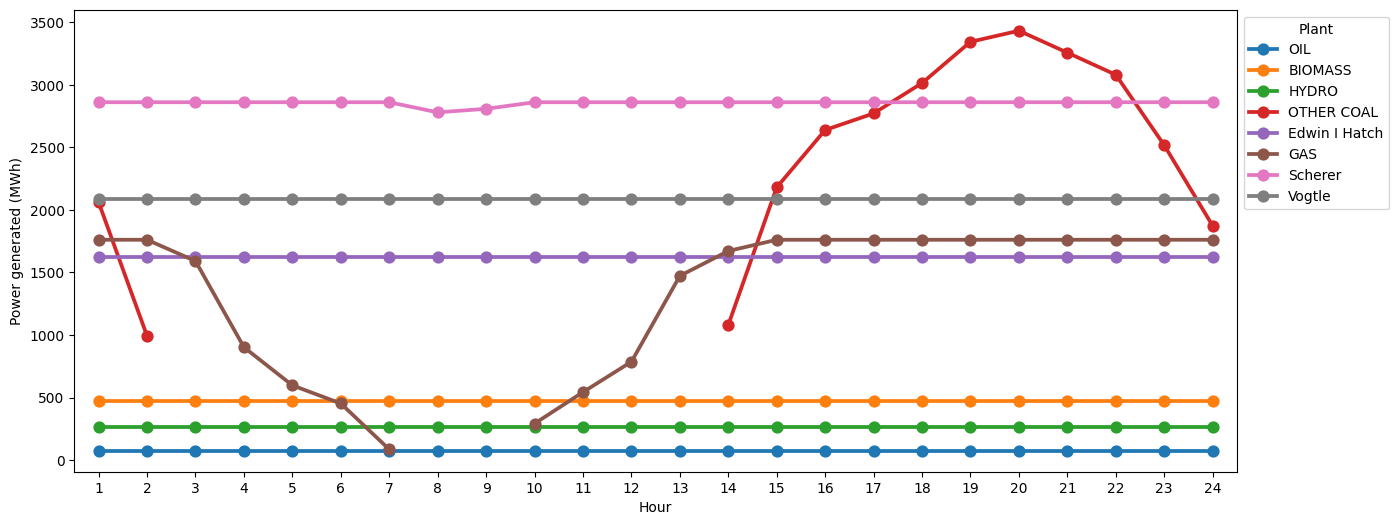

Power demand:


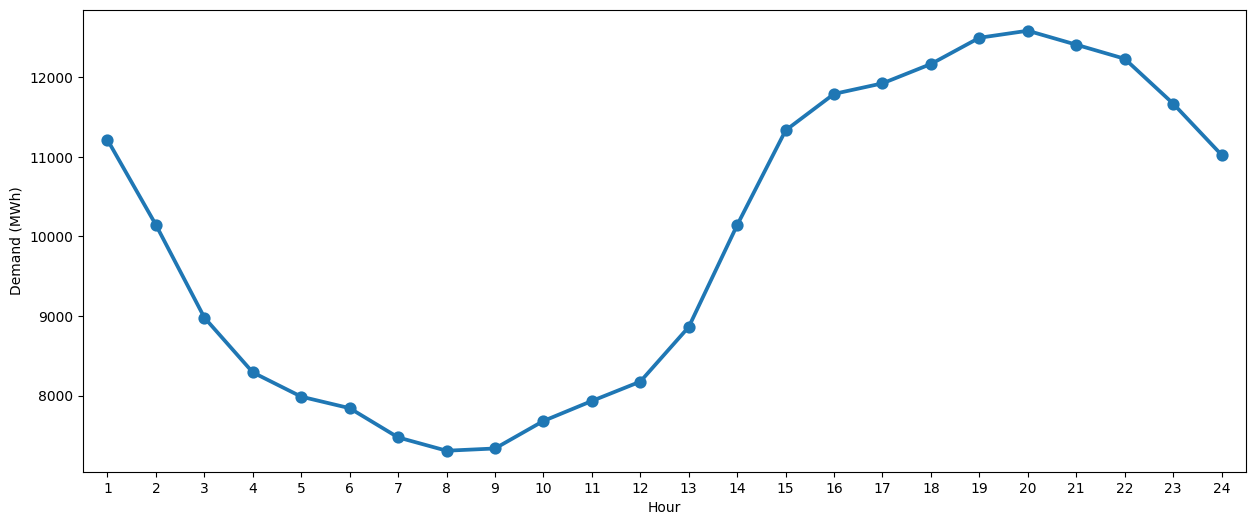

In [33]:
solution = pd.DataFrame()
solution = pd.DataFrame(columns=['Hour', 'Power (MWh)', 'Plant'])
plant_hour_pairs = [(h,i) for i in P for h in H  if z[i,h].X > 0]

solution['Hour'] = [pair[0] for pair in plant_hour_pairs]
solution['Plant'] = [pair[1] for pair in plant_hour_pairs]
solution['Power generated (MWh)'] = [z[pair[1],pair[0]].X for pair in plant_hour_pairs]

print("Power supply:")
fig, ax = plt.subplots(figsize=(15,6))
sns.pointplot(data=solution,x='Hour', y='Power generated (MWh)', hue='Plant')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

print("Power demand:")
fig, ax = plt.subplots(figsize=(15,6))
demand = pd.DataFrame(columns=['Hour', 'Demand (MWh)'])
demand['Hour'] = list(H)
demand['Demand (MWh)'] = [d[h] for h in H]
sns.pointplot(data=demand,x='Hour', y='Demand (MWh)')
plt.show()


The optimally cost-effective power schedule draws the bulk of the power from the coal plant Scherer and nuclear plants Vogtle and Edwin I Hatch.

In order to match the fluctuation in power demand over the 24 hours, we see fluctuations in power generation in some plants.
The bulk of the fluctuations is carried by the "Other coal" plant; an especially extreme scenario is where it is turned off in hour 2 and restarted in hour 14.
We see a similar fluctuation in the Gas plant.

### Optimal costs

Below is a breakdown of the costs incurred by this optimal power schedule. As expected, the fuel costs and health costs are the major contributors to the overall cost.

In [34]:
print("Fuel costs: $",round(sum(f[i]*z[i,h].X for i in P for h in H)*10**(-6),2),"million")
print("Health costs: $",round(sum(a[i,h]*z[i,h].X for i in P for h in H)*10**(-6),2),"million")
print("Operating costs: $",round(sum(o[i]*u[i,h].X for i in P for h in H),2))
print("Start-up costs: $",round(sum(s[i]*v[i,h].X for i in P for h in H),2))
print("Start-up costs: $",round(sum(s[i]*w[i,h].X for i in P for h in H),2))

Fuel costs: $ 4.29 million
Health costs: $ 0.2 million
Operating costs: $ 1622.73
Start-up costs: $ 219.0
Start-up costs: $ 219.0


###  Visualize the binary variables

We notice that the 'Other Coal' plant was switched "off" at one point and restarted at a later time. We can visualize how the switch "on" and "off" binary variables capture this scenario.

In [35]:
sol = pd.DataFrame()
plant = 'OTHER COAL'
sol['hour'] = [h for h in H]
sol['v[i,h]'] = [v[plant,h].X for h in H]
sol['w[i,h]'] = [w[plant,h].X for h in H]
sol['u[i,h]'] = [u[plant,h].X for h in H]
sol['z[i,h]'] = [z[plant,h].X for h in H]
sol

,hour,"v[i,h]","w[i,h]","u[i,h]","z[i,h]"
0,1,0.0,0.0,1.0,2060.91224
1,2,0.0,0.0,1.0,993.05342
2,3,0.0,1.0,0.0,0.00000
3,4,0.0,-0.0,0.0,0.00000
4,5,0.0,-0.0,0.0,0.00000
5,6,0.0,-0.0,0.0,0.00000
6,7,0.0,-0.0,0.0,0.00000
7,8,0.0,-0.0,-0.0,0.00000
8,9,0.0,-0.0,-0.0,0.00000
9,10,0.0,-0.0,-0.0,0.00000


## Full model

Below is the complete code to build and solve the optimization model.

In [36]:
import gurobipy as gp
from gurobipy import GRB
model = gp.Model("powergeneration")

# Define the variables
z = model.addVars(P,H,name="z", lb=0) # power generated in each plant for each hour
u = model.addVars(P,H,name="u", vtype=GRB.BINARY, lb=0) # is the plant on? for each plant and hour
v = model.addVars(P,H,name="v", vtype=GRB.BINARY) # start up the plant? for each plant and hour
w = model.addVars(P,H,name="w", vtype=GRB.BINARY) # shut down the plant? for each plant and hour

# Set the objective function by adding all the costs
objective = gp.quicksum(f[i]*z[i,h] for i in P for h in H) # fuel cost
objective += gp.quicksum(a[i,h]*z[i,h] for i in P for h in H) # health cost
objective += gp.quicksum(o[i]*u[i,h] for i in P for h in H) # operating cost
objective += gp.quicksum(s[i]*v[i,h] for i in P for h in H) # startup cost
objective += gp.quicksum(t[i]*w[i,h] for i in P for h in H) # shutdown cost
model.setObjective(objective,sense=GRB.MINIMIZE)

# Set the constraint to meet the demand
model.addConstrs((gp.quicksum(z[i,h] for i in P) == d[h]) for h in H)

# Set the constraint to set the minimum and maximum generation limits
model.addConstrs((z[i,h] >= m[i]*c[i]*u[i,h]) for i in P for h in H)
model.addConstrs((z[i,h] <= c[i]*u[i,h]) for i in P for h in H)

# Set the constraint to always keep the nuclear power plants on
model.addConstrs((z[i,h] >= m[i]*c[i]) for i in P_N for h in H)

# Set the constraint to ensure that the ramp-up and ramp-down speeds are within limits
model.addConstrs((z[i,h]-z[i,h-1]  >= -r[i]*c[i]) for i in P for h in H if h>1)
model.addConstrs((z[i,h]-z[i,h-1]  <= r[i]*c[i]) for i in P for h in H if h>1)

# Set the constraint to ensure that if the plant is turned on, the plant should be on
model.addConstrs((v[i,h] <= u[i,h]) for i in P for h in H)

# Set the constraint to ensure that if the plant is turned off, the plant should be off
model.addConstrs((w[i,h] <= 1-u[i,h]) for i in P for h in H)

# Set the constraint to link the startup/shutdown variables (v,w) to the on/off variables (u)
model.addConstrs((v[i,h] - w[i,h] == u[i,h] - u[i,h-1]) for i in P for h in H if h > 1)

# Solve the model
model.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 1722 rows, 960 columns and 4048 nonzeros (Min)
Model fingerprint: 0x1bed5def
Model has 792 linear objective coefficients
Variable types: 240 continuous, 720 integer (720 binary)
Coefficient statistics:
  Matrix range     [8e-01, 4e+03]
  Objective range  [5e+00, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+04]

Presolve removed 982 rows and 400 columns
Presolve time: 0.03s
Presolved: 740 rows, 560 columns, 2044 nonzeros
Variable types: 216 continuous, 344 integer (344 binary)
Found heuristic solution: objective 5286841.8503
Found heuristic solution: objective 4732800.2024

Root relaxation: objective 4.495125e+06, 184 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objectiv

Copyright © 2023 Gurobi Optimization, LLC

https://colab.research.google.com/github/Gurobi/modeling-examples/blob/master/optimization101/Modeling_Session_1/completed_Exercise_Set1.ipynb#scrollTo=1fc1f1ff-1a52-44a0-8238-218e768cd030

## **Exercise Set 2**

### True or False

**Q1.** Suppose the solar forecast for the week totaled more energy than the total demand. In this case it's guaranteed that no energy will be bought from the grid.
- True
- False

### Formualtion and Coding

In [37]:
%pip install gurobipy

import gurobipy as gp
from gurobipy import GRB

batteries = ["Battery0", "Battery1"]
time_periods = range(180)
capacity = {"Battery0": 60, "Battery1": 80}
p_loss = {"Battery0": 0.95, "Battery1": 0.9}
initial = {"Battery0": 20, "Battery1": 30}

m = gp.Model()

# flow_in = m.addVars(batteries, time_periods, name="flow_in")
# flow_out = m.addVars(batteries, time_periods, name="flow_out")
# grid = m.addVars(time_periods, name="grid")
# state = m.addVars(batteries, time_periods, name="state")
# gen = m.addVars(time_periods, name="gen")

Feel free to use the commented code above to copy and paste.

**Q2.** Write a line of code that sets the objective coefficients for the energy storage problem (minimizing grid electricity purchased) using the `addVars()` command. Check your code by writing to a file named `model.lp`

In [38]:
#### gurobipy code



**Q3.** [Depth of discharge](https://en.wikipedia.org/wiki/Depth_of_discharge) refers to the percentage a battery's level is below its capacity. To help maintain the batteries, a restriction is put into place that says the depth of discharge for **both batteries combined** cannot exceed 70% of the **total capacity**. Formulate constraints (write the inequalities algebraically) that model this and write code in gurobypi.

**Hints:** Make sure your generator expression is in parenthesis if you get an error and consider the initial state a few cells above.

Formulation:




In [39]:
#### gurobipy code
state = m.addVars(batteries, time_periods, name="state")



**Q4.** At the start of each day (other than the first) it is required that each battery be at least 40% full. The time periods for the start of each day are 30, 60, 90, 120, and 150. Formulate these constraints and write gurpbipy code. Do not worry about the solar forecast nor the contrstaint in **Q3**.

Formulation:

In [40]:
#### gurobipy code
m = gp.Model() # define the model again to make sure it is reset
state = m.addVars(batteries, time_periods, name="state")



### Modeling with Binary Variables

You have five light bulbs that are either on or off. Let $y_i = 1$ if lighbulb $i$ is on and $y_i = 0$ if it is off, for$\space i \in \{1,2,3,4,5\}$. Model the following statements using binary variables and $\le,\space\ge,\space=$. All questions are independent of each other.

**Q4.** No more than three of the lightbulbs can be on.

**Q5.** Lightbulb 2 or ligthbulb 3 must be on.

**Q6.** If lightbulb 1 is on, then lightbulb 5 is also on.

**Q7.** If lightbulb 1 is off, then lightbulb 3 is on.

**Q8.** If lightbulb 1 is off, then lightbulb 2 is off

**Q9.** Lightbulb 2 and lightbulb 4 are in opposite on/off states.

**Q10.** If any of lightbulbs 1 through 4 are on, then lighbtulb 5 is also on.

# Optimizing a power generation schedule


### Operating Costs

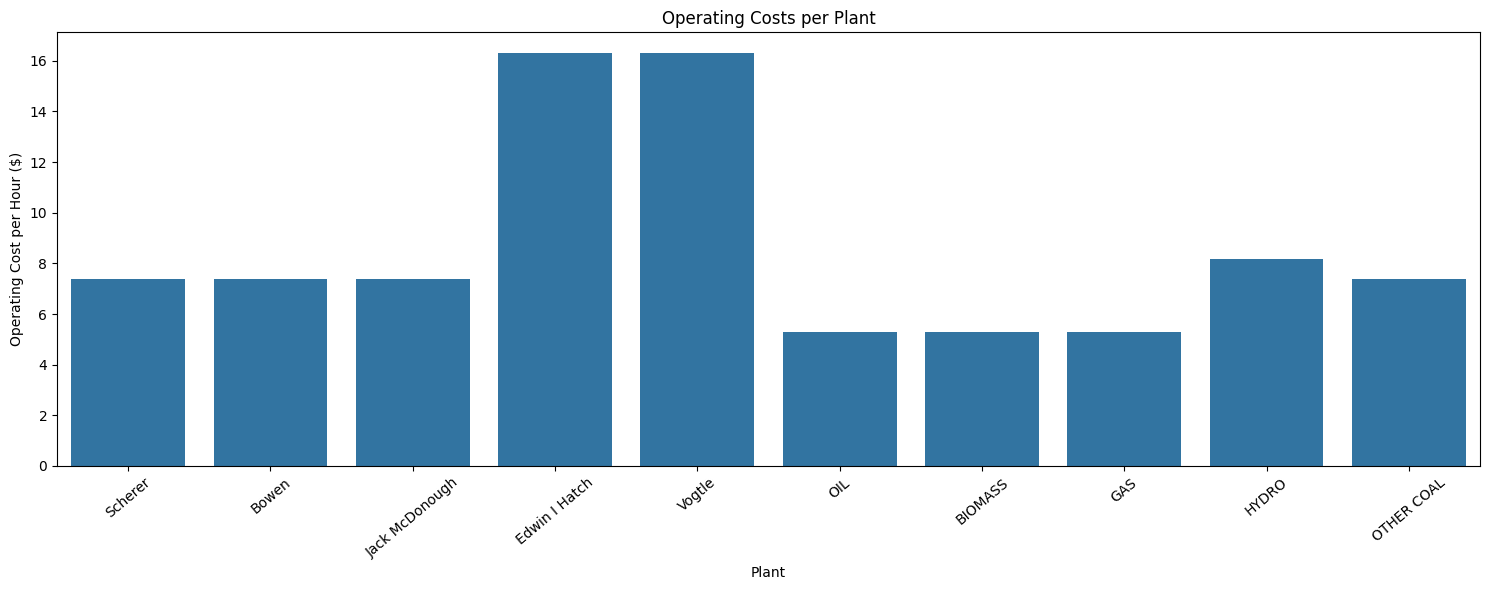

In [41]:
fig, ax = plt.subplots(figsize=(15,6))
oper_cost_plot = sns.barplot(x=list(o.keys()), y=[o[k] for k in o])
oper_cost_plot.set_xticklabels(oper_cost_plot.get_xticklabels(), rotation=40);
oper_cost_plot.set(xlabel='Plant', ylabel='Operating Cost per Hour ($)');
plt.title('Operating Costs per Plant')
plt.tight_layout()
plt.savefig('operating_costs.png')
plt.show()

### Startup Costs

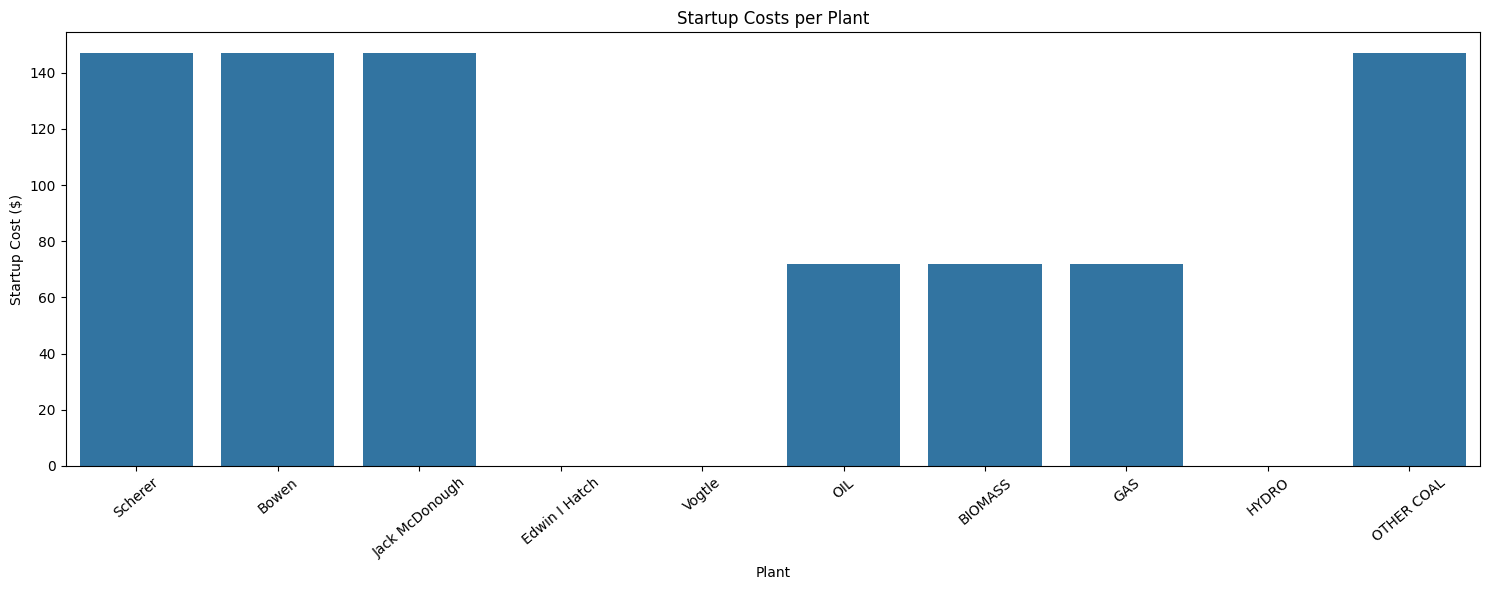

In [42]:
fig, ax = plt.subplots(figsize=(15,6))
startup_cost_plot = sns.barplot(x=list(s.keys()), y=[s[k] for k in s])
startup_cost_plot.set_xticklabels(startup_cost_plot.get_xticklabels(), rotation=40);
startup_cost_plot.set(xlabel='Plant', ylabel='Startup Cost ($)');
plt.title('Startup Costs per Plant')
plt.tight_layout()
plt.savefig('startup_costs.png')
plt.show()

### Ramp Up/Down Speed Limits

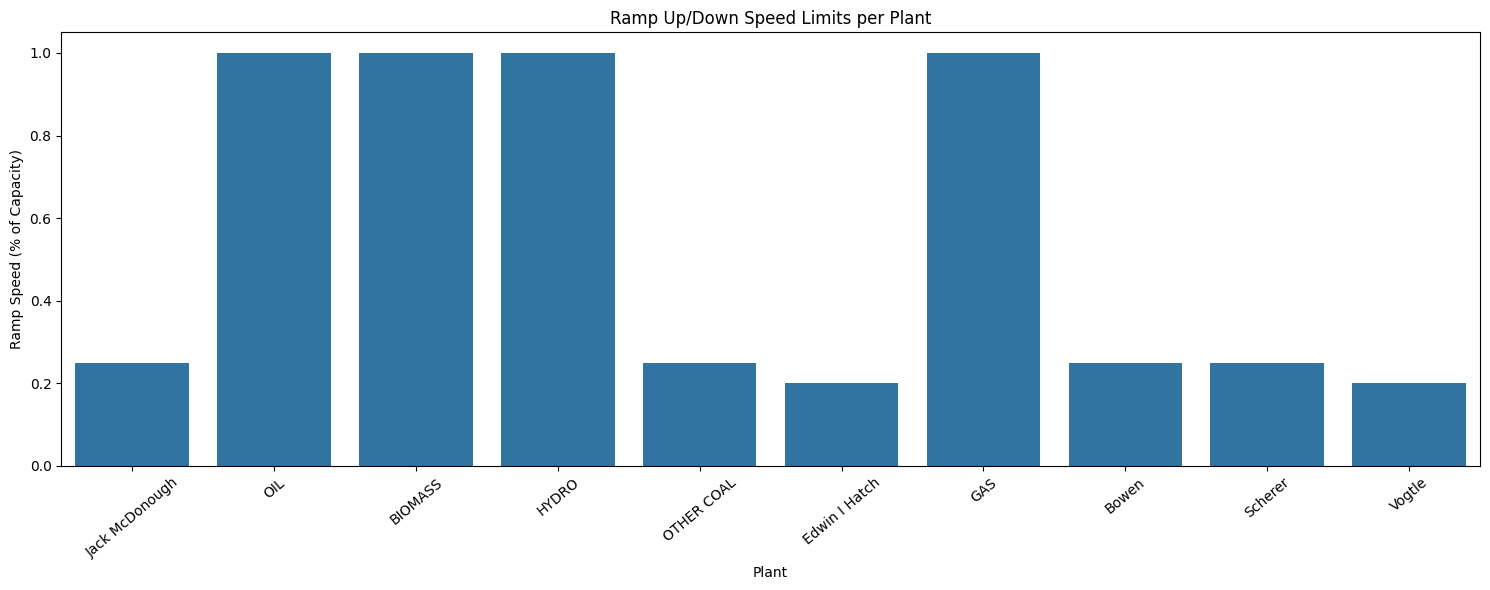

In [43]:
fig, ax = plt.subplots(figsize=(15,6))
ramp_speed_plot = sns.barplot(x=list(r.keys()), y=[r[k] for k in r])
ramp_speed_plot.set_xticklabels(ramp_speed_plot.get_xticklabels(), rotation=40);
ramp_speed_plot.set(xlabel='Plant', ylabel='Ramp Speed (% of Capacity)');
plt.title('Ramp Up/Down Speed Limits per Plant')
plt.tight_layout()
plt.savefig('ramp_speed_limits.png')
plt.show()

### Minimum Generation Percentage

AttributeError: 'gurobipy.Model' object has no attribute 'keys'

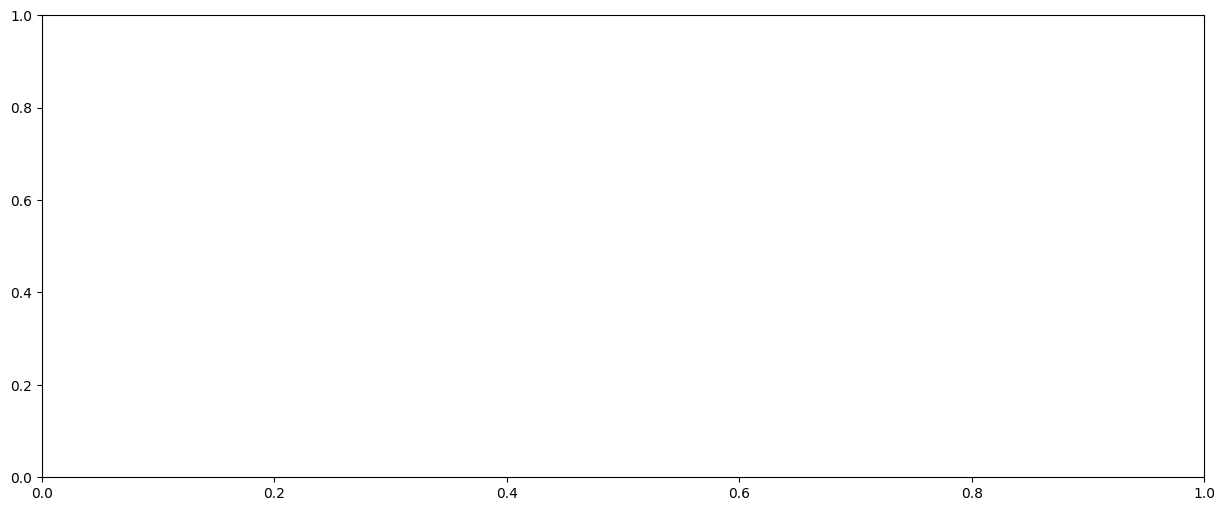

In [44]:
fig, ax = plt.subplots(figsize=(15,6))
min_gen_plot = sns.barplot(x=list(m.keys()), y=[m[k] for k in m])
min_gen_plot.set_xticklabels(min_gen_plot.get_xticklabels(), rotation=40);
min_gen_plot.set(xlabel='Plant', ylabel='Minimum Generation Percentage');
plt.title('Minimum Generation Percentage per Plant (when on)')
plt.tight_layout()
plt.savefig('min_generation_percentage.png')
plt.show()

### Total Optimization Objective Value

In [ ]:
print(f"Optimal Objective Value (Total Cost): ${model.objVal:,.2f}")

### Optimal Cost Breakdown Visualization

In [ ]:
fuel_cost = sum(f[i]*z[i,h].X for i in P for h in H)
health_cost = sum(a[i,h]*z[i,h].X for i in P for h in H)
operating_cost = sum(o[i]*u[i,h].X for i in P for h in H)
startup_cost = sum(s[i]*v[i,h].X for i in P for h in H)
shutdown_cost = sum(t[i]*w[i,h].X for i in P for h in H)

costs_data = {
    'Cost Type': ['Fuel Costs', 'Health Costs', 'Operating Costs', 'Start-up Costs', 'Shut-down Costs'],
    'Amount ($)': [fuel_cost, health_cost, operating_cost, startup_cost, shutdown_cost]
}
df_costs = pd.DataFrame(costs_data)

fig, ax = plt.subplots(figsize=(10, 8))
colors = sns.color_palette('pastel')[0:5]
ax.pie(df_costs['Amount ($)'], labels=df_costs['Cost Type'], colors=colors, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(centre_circle)
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Breakdown of Total Optimal Costs')
plt.tight_layout()
plt.savefig('cost_breakdown_pie_chart.png')
plt.show()

The electricity grid powers nearly every aspect of modern life — be it charging a phone, powering a factory, or mining Bitcoin.
Energy sector decision-makers must ensure a smooth and adequate power supply that caters to the growing power needs of modern life.
After all, with great power comes great responsibility.

In [ ]:
from PIL import Image
import requests
from io import BytesIO

print('Nuclear power plants. Source: Daniel Prudek / Shutterstock).')
img = Image.open(BytesIO(requests.get('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/image_powerplant.png?raw=true').content))
img
# Image('image_powerplant.png')

Managing the supply and demand of electricity can be a complex and challenging task. Suppose that we are in charge of generating power for the U.S. State of Georgia. Assume that we know the set of all available power plants and the demand for power for each hour of a day. Can we create a schedule to decide how much power each plant should generate, and when to switch the plants "on" and "off"? How can we do so while minimizing the overall costs?

In this notebook, we model this decision-making problem using **mathematical optimization**. The first part of the notebook describes the datasets used. We use real data from the State of Georgia with a population of 10.8 million people. The data includes historical demand for power as well as specific information about the power plants.

The second part of the notebook introduces the three components of a mathematical optimization model: the objective function to be optimized, the decision variables, and the constraints. In our power generation problem, the **objective** is to minimize the overall costs. The **decision variables** model the power generation schedule. The **constraints** capture basic requirements such as ensuring that the power supply meets the demand, as well as practical limitations such as the minimum and maximum production levels for each power plant. By finding the optimally cost-efficient schedule, this model helps power plant operators get the best output from their facilities while minimizing the overall costs.


Let's get started.

## The data

First, let us load the following packages needed to process and visualize the data.

In [ ]:
%pip install networkx seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Historical power demand data

First, read the demand data.
The 'demand.csv' file contains the historical demand for power in the State of Georgia from 2004 to 2013.
This data is available for each hour of the 31 days of two months --- summer month (July) and a winter month (January).

For the rest of this notebook, we will pick a date, say July 1st, 2011.

We store the demand as a dictionary indexed by each hour (between 1 and 24) and valued by the amount of power needed.

In [ ]:
df_load_curves = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/demand.csv?raw=true')
# df_load_curves = pd.read_csv('demand.csv')

# select the demand for the chosen day (July 1st, 2011)
df_subset = df_load_curves[(df_load_curves['YEAR']==2011)&(df_load_curves['MONTH']==7)&(df_load_curves['DAY']==1)]

# store the demand to a dicionary
d = df_subset.set_index(['HOUR']).LOAD.to_dict()

H = set(d.keys()) # set of hours in a day (1 through 24)

We can visualize the power usage in Georgia on July 1st, 2011.

In [ ]:
fig, ax = plt.subplots(figsize=(15,6))
demand_plot = sns.barplot(x=list(range(1,25)), y=[d[h] for h in range(1,25)])
demand_plot.set_xticklabels(demand_plot.get_xticklabels());
demand_plot.set(xlabel='Hour', ylabel='Demand (MWh)');
plt.show()

The power utilization is higher in the evenings than in the mornings.

### Power plant data

Next, let us load information about the power plants.

The real dataset is **large**, with 99 power plants. Solving the optimization problem using the large dataset requires a full Gurobi license.
If you are an academic (student or faculty), you can request a free Gurobi license [here](https://www.gurobi.com/academia/academic-program-and-licenses/).
To use the Gurobipy package without a license, this notebook uses a simplified smaller dataset with **ten groups** of power plants.
To test the model with the full data, simply replace 'small_plant_data' with 'large_plant_data' in the rest of the code.

Power plants come in different types based on the type of fuel they consume.
From our dataset, there are **six types** of power plants: coal, nuclear, oil, gas hydro, and biomass.
In the small data used in this notebook, we have ten power plants - namely two nuclear plants (Edwin I Hatch and Vogtle) and three coal plants (Bowen, Jack McDonough and Scherer), with rest of the coal plants grouped into one mega-plant named 'OTHER COAL', and four groups of merged plants for each of the four plant types, named 'BIOMASS', 'GAS', 'HYDRO', and 'OIL'.

The **fuel** used by each power plant is also loaded from the files. This information is necessary to determine some of the fuel-dependent costs.

We now load this data.

In [ ]:
df_plant_info = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/plant_capacities.csv?raw=true') # replace "small_plant_data" with "large_plant_data" to use the full dataset
# df_plant_info = pd.read_csv('small_plant_data/plant_capacities.csv')

P = set(df_plant_info['Plant'].unique())                          # set of all power plants

plant_type = df_plant_info.set_index('Plant').PlantType.to_dict() # plant type for each plant

P_N = set([i for i in P if plant_type[i]=='NUCLEAR'])             # set of all nuclear plants

fuel_type = df_plant_info.set_index('Plant').FuelType.to_dict()   # fuel type for each plant


### Plant capacities and limits

The overall goal is to determine the amount of power to generate from each plant. This amount must be within the plant's minimum and maximum production limits (in MWh). See below for a visualization of the maximum production limits for the ten plants.

In [ ]:
df_plant_info['capacity'] = df_plant_info['Capacity']
c = df_plant_info.set_index('Plant').capacity.to_dict() # generation capacity

capacity_plot = sns.barplot(x=list(c.keys()), y=[c[k] for k in c])
capacity_plot.set_xticklabels(capacity_plot.get_xticklabels(), rotation=40);
capacity_plot.set(xlabel='Plant', ylabel='Capacity (MWh)');
plt.show()

Clearly, coal plants are capable of the highest production capacities, followed by nuclear and hydro plants.

Moreover, if a nuclear power plant is turned "on," it has to generate at least 80% of its maximum capacity. For the rest of the plants, we set this minimum limit to 1%.

In [ ]:
m = {i: 0.8 if i in P_N else 0.01 for i in P} # min % generation when on

Additionally, we also have a limit on how much the power generation schedule can **ramp up** or **ramp down** the power generation between successive hours.
This limit ensures that the plants are not forced make drastic changes to their generation schedule.

We set this speed limit to be **20%** for nuclear plants and **25%** for coal plants. In other words, a coal plant cannot be ramped up or ramped down within an hour by more than 25% of its total capacity.
We set the speed limit to be **100%** for all other plants thereby imposing no limit on the speed.

In [ ]:
r = {i: 1 if i in ['BIOMASS','GAS','HYDRO','OIL'] else .2 if i in P_N else .25 for i in P}  # ramp up/down speed (plant)

### Costs

Finally, we load the cost data. There are five types of costs: fuel costs, operating costs, start-up and shut-down costs, and health costs.
We have historical yearly average data (for 2004-2011) on these costs based on fuel type.
For the rest of the notebook, we will use the average costs for 2011.

First is the **fuel costs**, which measure the cost of producing *one* MWh of power.
As visualized below, the coal and gas fuel types are the most expensive, while nuclear is the least expensive.

In [ ]:
df_fuel_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/fuel_costs.csv?raw=true')
# df_fuel_costs = pd.read_csv('small_plant_data/fuel_costs.csv')

# read the fuel costs and transform it from fuel-type to plant-name
f = {i: df_fuel_costs[df_fuel_costs['year']==2011].T.to_dict()[9][fuel_type[i]] for i in fuel_type} # dictionary of fuel cost for each plant

# plot the fuel costs
fuelcost_plot = sns.barplot(x=list(f.keys()), y=[f[k] for k in f])
fuelcost_plot.set_xticklabels(fuelcost_plot.get_xticklabels(), rotation=40);
fuelcost_plot.set(xlabel='Plant', ylabel='Fuel cost per MWh ($)');
plt.show()

The second is the **operation costs**, which is the cost per hour of keeping a power plant on.

In [ ]:
df_oper_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/operating_costs.csv?raw=true')
# df_oper_costs = pd.read_csv('small_plant_data/operating_costs.csv')
o = {i: df_oper_costs[df_oper_costs['year']==2011].T.to_dict()[9][fuel_type[i]] for i in fuel_type} # operating cost/MWh (plant)

The third and fourth are the **startup** and **shutdown costs**, which penalize whenever a plant is started up and shut down. Incorporating these costs in the model ensures a stable power generation schedule.

In [ ]:
df_startup_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/startup_costs.csv?raw=true')
# df_startup_costs = pd.read_csv('small_plant_data/startup_costs.csv')
s = {i: df_startup_costs[df_startup_costs['year']==2011].T.to_dict()[9][fuel_type[i]] for i in fuel_type} # operating cost/MWh (plant)

t = s.copy() # assume that the cost of shuting down = starting up

Finally, we load the **health costs**, which capture the health effects of burning too much coal. This data is only available for the three coal plants (Bowen, Jack McDonough and Scherer).


The health costs are aggregated using a variety of environmental factors that depend on the time of the day. As a result, these costs are indexed for each hour. See the visualization below for health costs for the Bowen power plant to observe that the costs are much higher in the evenings than in the mornings.

In [ ]:
df_health_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/health_costs.csv?raw=true')
# df_health_costs = pd.read_csv('small_plant_data/health_costs.csv')
a = df_health_costs[(df_health_costs['Year']==2007)&(df_health_costs['Day']==1)].set_index(['Plant','Hour']).to_dict()['Cost'] # operating cost/MWh (plant)
a.update({(i,h): 0 for i in P for h in H if i not in ['Bowen','Jack McDonough','Scherer']})

fig, ax = plt.subplots(figsize=(15,6))
healthcost_plot = sns.barplot(x=list(range(1,25)), y=[a['Bowen',h] for h in range(1,25)])
healthcost_plot.set_xticklabels(healthcost_plot.get_xticklabels());
healthcost_plot.set(xlabel='Hour', ylabel='Health costs in Bowen ($)');
plt.show()

## Optimization model

We will now address the decision-making problem.
Using the ten power plants, and knowing their capabilities and limitations, what is the most cost-effective way to generate power from them in order to completely satisfy the energy demand in Georgia?

We can capture these complex considerations in a mathematical optimization model.
An optimization model finds the **best solution** according to an **objective function** such that the solution satisfies a set of **constraints**.
Here, a solution is expressed as a vector of real values or integer values called **decision variables**.
Constraints are a set of equations or inequalities written as a function of the decision variables.

For our power generation problem, the objective is to minimize the overall costs.
The decision variables represent the power generation schedule for each power plant.
The limits and capacities of the power plants are captured using the constraints.

Let us now define the inputs to the model. The subscripts $i$ and $h$ will be used to denote each power plant and hour, respectively.

### Input Parameters
Sets:
- $P\ (P_N)$: set of (nuclear) power plants,
- $H$: set of hours.

Demand, capacity and speed limits:
- $d_h$: power demand for each hour $h$,
- $c_i$: maximum power generation capacity for power plant $i$,
- $m_i$: minimum % power that must be generated from power plant $i$,
- $r_i$: ramp up/ramp down speed for power plant $i$.

Costs:
- $f_i, o_i$: fuel and operating costs for power plant $i$,
- $a_{ih}$: health costs for power plant $i$ in hour $h$,
- $s_i, t_i$: startup and shutdown costs for power plant $i$.

We have already loaded these parameters and have stored each input as a dictionary.

The following code loads the Gurobi python package and initiates the optimization model.

In [ ]:
%pip install gurobipy
import gurobipy as gp
from gurobipy import GRB
model = gp.Model("powergeneration")

Having initiated the optimization model, we will now build the model step by step by adding the variables, objective and constraints.

First, we will define the decision variables.
There are several types of variables based on the range of values they can take.
A **continuous** variable can take any real value within lower and upper bounds, whereas a **binary** variable can be either 0 or 1.

Our key decision variable is a continuous variable.
Let $z_{i,h}$ be the amount of power to be generated from power plant $i$ during hour $h$; this has to be *at least* $0$.

We can add this variable to the model using gurobipy's **addVars** function.

In [ ]:
z = model.addVars(P, H, name="z", lb=0)             # power generated in each plant for each hour

The rest of the decision variables in our model are binary variables, meaning they act as on/off switches.
Let $u_{i,h}$ be an indicator of whether plant $i$ is *on* during hour $h$.
Further, let $v_{i,h}$ and $w_{i,h}$ be indicators of whether plant $i$ is *started up* or *shut down*, respectively, for hour $h$.
Each of these variables takes the value $1$ if true, or $0$ otherwise.

We now add these binary variables to the model using the **addVars** function.

In [ ]:
u = model.addVars(P, H, name="u", vtype=GRB.BINARY) # is the plant on? for each plant and hour

v = model.addVars(P, H, name="v", vtype=GRB.BINARY) # start up the plant? for each plant and hour

w = model.addVars(P, H, name="w", vtype=GRB.BINARY) # shut down the plant? for each plant and hour

print("This model has",len(z)+len(u)+len(v)+len(w),"decision variables.")

model.update()

### Objective: Minimize the total costs

Having defined the variables, we now tell the model what to optimize for.
We want to minimize the overall costs composed of five components - fuel, health, operating, startup and shutdown costs.
We can mathematically express the total cost using the decision variables as the following,

\begin{align*}
\sum_{\textrm{plant}\ i} \sum_{\textrm{hour}\ h} (f_i z_{i,h} + a_{i,h} z_{i,h} + o_i u_{i,h} + s_i v_{i,h} + t_i w_{i,h})
\end{align*}

We now add this objective function to the model using the **setObjective** function.
The key input is the summation of all the terms.
Below is one way to add the five components one by one.

In [ ]:
objective = gp.quicksum(f[i]*z[i,h] for i in P for h in H) # fuel cost
objective += gp.quicksum(a[i,h]*z[i,h] for i in P for h in H) # health cost
objective += gp.quicksum(o[i]*u[i,h] for i in P for h in H) # operating cost
objective += gp.quicksum(s[i]*v[i,h] for i in P for h in H) # startup cost
objective += gp.quicksum(t[i]*w[i,h] for i in P for h in H) # shutdown cost
model.setObjective(objective, sense=GRB.MINIMIZE)

Next, we tell the model what range of values the decision variables can take. This is done through *constraints*.

### Constraint: Meet demand

First, we want to make sure that the total power generated by all the power plants in each hour is equal to the power demand in that hour.
This requirement can be mathematically expressed as the following equality constriant for each hour $h$.

\begin{align*}
\sum_{\textrm{plant}\ i} z_{i,h} &= d_h
\end{align*}

We now add this constriant to our model using the **addConstrs** function.

In [ ]:
model.addConstrs((gp.quicksum(z[i,h] for i in P) == d[h]) for h in H)

model.update()

### Constraint:  Maximum and minimum generation levels

We make sure that the power generated from each plant does not exceed the plant's maximum capacity (denoted by $c_i$). This constraint can be expressed by the inequality $z_{i,h} \leq c_i$ for each plant and hour.
We also want to make sure that when the plant is "off", i.e. when $u_{i,h}=0$, we do not generate any power, i.e. $z_{i,h}=0$.
We can capture this by the following inequality for each plant $i$ and hour $h$,

\begin{align*}
z_{i,h} \leq c_i u_{i,h}
\end{align*}

Furthermore, recall that each plant needs to generate a certain minimum % amount of power (denoted by $m_i$).
Nuclear power plants must produce at least 80% of their capacity and the rest of the plants must produce at least 1% of their capacity.
This can be expressed by the following inequality for each power plant $i$ and hour $h$,

\begin{align*}
z_{i,h}  \geq m_i c_i u_{i,h}
\end{align*}

Note that this constraint also ensures that when there is no power generated, i.e., $z_{i,h} = 0$, then the plant is said to be turned "off", i.e., $u_{i,h} =0$.

We now add these constraints to the model.

In [ ]:
model.addConstrs((z[i,h] <= c[i]*u[i,h]) for i in P for h in H)

model.addConstrs((z[i,h] >= m[i]*c[i]*u[i,h]) for i in P for h in H)

model.update()

### Constraint:  Nuclear plants are always on

Unlike the other types of power plants, nuclear power plants cannot be easily shut down within a short period of time.
In our model, we add a constriant that ensures that the nuclear power plants are always "on".
This can be done either by setting the $u$ variable to be $1$, or the following for each nuclear plant $i$ and hour $h$:

\begin{align*}
 z_{i,h} \geq m_i c_i
\end{align*}

We now add these constraints to the model.

In [ ]:
model.addConstrs((z[i,h] >= m[i]*c[i]) for i in P_N for h in H)

model.update()

### Constraint:  Max rampdown, rampup


While operating the power plants, it is preferable not to cause drastic changes in power generation.
We can enforce a limit on the speed at which power generation is ramped up or ramped down.
For each plant $i$, the quantity $z_{i,h} - z_{i,h-1}$ gives the difference in power generated between hours $h-1$ and $h$.


We can define constraints that ensure that the magnitude of  quantity is no more than a certain percentage of the maximum capacity.
This percentage is given by the ramp up/ramp down speed denoted by $r_i$.
These constraints can be mathematically expressed as the following for each plant $i$ and hour $h>1$,

\begin{align*}
-r_i c_i   \leq z_{i,h} - z_{i,h-1} \leq r_i c_i
\end{align*}

We now add these constraints to the model.

In [ ]:
model.addConstrs((z[i,h]-z[i,h-1] >= -r[i]*c[i]) for i in P for h in H if h>1)

model.addConstrs((z[i,h]-z[i,h-1] <= r[i]*c[i]) for i in P for h in H if h>1)

model.update()

### Constraint:  If switched on, must be on

Next, we ensure that when a power plant is switched "on," the plant is "on" (and in effect starts generating power).
Mathematically, when $v_{i,h}$ is $1$, $u_{i,h}$ is set to $1$.
Similarly, when a plant is "switched off," the plant is "off"; when $w_{i,h}$ is $1$, $u_{i,h}$ is set to $0$.

These constraints are linear inequalities expressed as the following for each plant $i$ and hour $h$,

\begin{align*}
v_{i,h} \leq u_{i,h},\\
w_{i,h} \leq 1 - u_{i,h}
\end{align*}

We now add these constraints to the model.

In [ ]:
model.addConstrs((v[i,h] <= u[i,h]) for i in P for h in H)

model.addConstrs((w[i,h] <= 1-u[i,h]) for i in P for h in H)

model.update()

### Constraint:  Link startup/shutdown variables to "on"/"off" variables

Finally, we link the startup/shutdown variables ($v$ and $w$) with the "on"/"off" variables ($u$).
Comparing two successive hours $h-1$ and $h$, the quantity $u_{i,h} - u_{i,h-1}$ can take one of three possible values: -1, 0, 1.
If it is -1, it means that the plant is "switched off" for hour $h$, forcing the variable $w_{i,h}$ to be $1$.
If it is 1, it means that the plant is "switched on" for hour $h$, forcing the variable $v_{i,h}$ to be $1$.
If it is 0, it means that the plant is neither "switched on" nor "switched off" for hour $h$; forcing the variables $w_{i,h}$ and $v_{i,h}$ to be $0$.

All of these possible combinations can be elegantly expressed using the following equality constraint for each plant $i$ and hour $h>1$,

\begin{align*}
v_{i,h} - w_{i,h} = u_{i,h} - u_{i,h-1}
\end{align*}

We now add these constraints to the model.

In [ ]:
model.addConstrs((v[i,h] - w[i,h] == u[i,h] - u[i,h-1]) for i in P for h in H if h > 1)

model.update()

### Solve the model

Voila! We have completed building the model and we can solve the model using a call to **optimize()**.

In [ ]:
model.optimize()

We have solved the model!

### Optimal power schedule

We now visualize the power generation schedule. The following code retrieves the optimal values for the decision variables by simply adding .X to each variable. We then visualize the amount of power generated by each plant for 24 hours and compare it to the power demand curve.

In [ ]:
solution = pd.DataFrame()
solution = pd.DataFrame(columns=['Hour', 'Power (MWh)', 'Plant'])
plant_hour_pairs = [(h,i) for i in P for h in H  if z[i,h].X > 0]

solution['Hour'] = [pair[0] for pair in plant_hour_pairs]
solution['Plant'] = [pair[1] for pair in plant_hour_pairs]
solution['Power generated (MWh)'] = [z[pair[1],pair[0]].X for pair in plant_hour_pairs]

print("Power supply:")
fig, ax = plt.subplots(figsize=(15,6))
sns.pointplot(data=solution,x='Hour', y='Power generated (MWh)', hue='Plant')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

print("Power demand:")
fig, ax = plt.subplots(figsize=(15,6))
demand = pd.DataFrame(columns=['Hour', 'Demand (MWh)'])
demand['Hour'] = list(H)
demand['Demand (MWh)'] = [d[h] for h in H]
sns.pointplot(data=demand,x='Hour', y='Demand (MWh)')
plt.show()


The optimally cost-effective power schedule draws the bulk of the power from the coal plant Scherer and nuclear plants Vogtle and Edwin I Hatch.

In order to match the fluctuation in power demand over the 24 hours, we see fluctuations in power generation in some plants.
The bulk of the fluctuations is carried by the "Other coal" plant; an especially extreme scenario is where it is turned off in hour 2 and restarted in hour 14.
We see a similar fluctuation in the Gas plant.

### Optimal costs

Below is a breakdown of the costs incurred by this optimal power schedule. As expected, the fuel costs and health costs are the major contributors to the overall cost.

In [ ]:
print("Fuel costs: $",round(sum(f[i]*z[i,h].X for i in P for h in H)*10**(-6),2),"million")
print("Health costs: $",round(sum(a[i,h]*z[i,h].X for i in P for h in H)*10**(-6),2),"million")
print("Operating costs: $",round(sum(o[i]*u[i,h].X for i in P for h in H),2))
print("Start-up costs: $",round(sum(s[i]*v[i,h].X for i in P for h in H),2))
print("Start-up costs: $",round(sum(s[i]*w[i,h].X for i in P for h in H),2))

###  Visualize the binary variables

We notice that the 'Other Coal' plant was switched "off" at one point and restarted at a later time. We can visualize how the switch "on" and "off" binary variables capture this scenario.

In [ ]:
sol = pd.DataFrame()
plant = 'OTHER COAL'
sol['hour'] = [h for h in H]
sol['v[i,h]'] = [v[plant,h].X for h in H]
sol['w[i,h]'] = [w[plant,h].X for h in H]
sol['u[i,h]'] = [u[plant,h].X for h in H]
sol['z[i,h]'] = [z[plant,h].X for h in H]
sol

## Full model

Below is the complete code to build and solve the optimization model.

In [ ]:
import gurobipy as gp
from gurobipy import GRB
model = gp.Model("powergeneration")

# Define the variables
z = model.addVars(P,H,name="z", lb=0) # power generated in each plant for each hour
u = model.addVars(P,H,name="u", vtype=GRB.BINARY, lb=0) # is the plant on? for each plant and hour
v = model.addVars(P,H,name="v", vtype=GRB.BINARY) # start up the plant? for each plant and hour
w = model.addVars(P,H,name="w", vtype=GRB.BINARY) # shut down the plant? for each plant and hour

# Set the objective function by adding all the costs
objective = gp.quicksum(f[i]*z[i,h] for i in P for h in H) # fuel cost
objective += gp.quicksum(a[i,h]*z[i,h] for i in P for h in H) # health cost
objective += gp.quicksum(o[i]*u[i,h] for i in P for h in H) # operating cost
objective += gp.quicksum(s[i]*v[i,h] for i in P for h in H) # startup cost
objective += gp.quicksum(t[i]*w[i,h] for i in P for h in H) # shutdown cost
model.setObjective(objective,sense=GRB.MINIMIZE)

# Set the constraint to meet the demand
model.addConstrs((gp.quicksum(z[i,h] for i in P) == d[h]) for h in H)

# Set the constraint to set the minimum and maximum generation limits
model.addConstrs((z[i,h] >= m[i]*c[i]*u[i,h]) for i in P for h in H)
model.addConstrs((z[i,h] <= c[i]*u[i,h]) for i in P for h in H)

# Set the constraint to always keep the nuclear power plants on
model.addConstrs((z[i,h] >= m[i]*c[i]) for i in P_N for h in H)

# Set the constraint to ensure that the ramp-up and ramp-down speeds are within limits
model.addConstrs((z[i,h]-z[i,h-1]  >= -r[i]*c[i]) for i in P for h in H if h>1)
model.addConstrs((z[i,h]-z[i,h-1]  <= r[i]*c[i]) for i in P for h in H if h>1)

# Set the constraint to ensure that if the plant is turned on, the plant should be on
model.addConstrs((v[i,h] <= u[i,h]) for i in P for h in H)

# Set the constraint to ensure that if the plant is turned off, the plant should be off
model.addConstrs((w[i,h] <= 1-u[i,h]) for i in P for h in H)

# Set the constraint to link the startup/shutdown variables (v,w) to the on/off variables (u)
model.addConstrs((v[i,h] - w[i,h] == u[i,h] - u[i,h-1]) for i in P for h in H if h > 1)

# Solve the model
model.optimize()

Copyright © 2023 Gurobi Optimization, LLC

## Exercise Set 1

### Multiple Choice
**Q1.** Which of these are NOT key components for an optimization model?
- decision variables
- parameters
- objective function
- `hyperparameters`

**Q2.** MO can be used as a strict replacement for nearly all ML problems
- True
- `False`

**Q3.** ML can be used as a strict replacement for nearly all MO problems
- True
- `False`

**Q4.** Which of the following is a type of decision variables in mathematical optimization?
- `binary`
- complex
- feature
- complimentary

**Q5.** To solve a mixed-integer program, a solver may need to solve this many linear programs:
- none
- the number of decision variables
- the number of total constraints
- `possibly exponentially many`

**Q6.** It is required that you or your data analytics team develop an expertise in `predictive` analytics before attempting `prescriptive` analytics (like mathematical optimization).
- True
- `False`

**Q7.** The `feasible region` of a linear program (LP) will have ____ points in it than its corresponding mixed-integer program (MIP), assuming the two models are exactly the same other than the LP has only continuous variables and the MIP contains integer variables.
- `more`
- less
- always exactly the same

**Q8.** Unless specified, the default variable type when using `addVars()` is **continuous**.
- `True`
- False

Let $J = \{\texttt{Apple, Banana, Coconut, Dragonfruit, Elderberry, Fig, Gooseberry}\}$ and $T = \{1, 2, 3, 4\}$

**Q9-a.** Adding decision variables using `addVars(J,...)` and `addVars(range(8),...)` will add the *same* number of variables to a model
- True
- `False`

**Q9-b.** Using the sets above, adding decision variables using `addVars(J, T,...)` and `addVars(range(28),...)` will add the *same* number of variables to a model
- `True`
- False

### Formulation and Coding
Below is code for the entire original model in one cell if you would like to use it to help with these exercises.

In [ ]:
%pip install gurobipy

import pandas as pd
import gurobipy as gp
from gurobipy import GRB

production = ['Baltimore','Cleveland','Little Rock','Birmingham','Charleston']
distribution = ['Columbia','Indianapolis','Lexington','Nashville','Richmond','St. Louis']

path = 'https://raw.githubusercontent.com/Gurobi/modeling-examples/master/optimization101/Modeling_Session_1/'
transp_cost = pd.read_csv(path + 'cost.csv', index_col=[0,1]).squeeze("columns")
max_prod = pd.Series([180,200,140,80,180], index = production, name = "max_production")
n_demand = pd.Series([89,95,121,101,116,181], index = distribution, name = "demand")
frac = 0.75

m = gp.Model('widgets')
x = m.addVars(production, distribution, name = 'prod_ship')
meet_demand = m.addConstrs((gp.quicksum(x[p,d] for p in production) >= n_demand[d] for d in distribution), name = 'meet_demand')
can_produce = m.addConstrs((gp.quicksum(x[p,d] for d in distribution) <= max_prod[p] for p in production), name = 'can_produce')
must_produce = m.addConstrs((gp.quicksum(x[p,d] for d in distribution) >= frac*max_prod[p] for p in production), name = 'must_produce')
m.setObjective(gp.quicksum(transp_cost[i,j]*x[i,j] for i in production for j in distribution), GRB.MINIMIZE)
m.optimize()

You are told there is a new policy for transporting **widgets** from production facilities. It is now required that the minimum number of widgets shipped from any production facility to any distribution center needs to be at least 20.

**Q10-a.** Write out how the formulation changes using mathematical notation given the new requirement.

\begin{align*}
x_{p,d} \ge 20, \quad \forall p \in P, d \in D
\end{align*}

**Q10-b.** Write the changes for **Q10-a** in gurobipy code in the cell below (no need to run it, unless you want to copy the model here to check).

In [ ]:
m.addConstrs(x[p,d] >= 20 for p in production for d in distribution)
m.update()

The initial widget model $m$ represented a single time period (e.g. a week, month, quarter). Suppose we added a time component using a set $T = \{0, 1, 2, 3\}$ representing a quarter of a year.

**Q11-a.** Use `addVar()` or `addVars()` to create a decision variable in gurobipy that represents the number of widgets shipped from a production facility to a distribution center for a given time period.

In [ ]:
x = m.addVars(production, distribution, range(4), name = 'prod_ship')

**Q11-b.** To reference a time period before a given time $t$, we can use $t-1$ as a subscript (since $T$ is a set of integers), but $t-1$ doesn't work when $t = 0$ since $-1$ isn't in $T$. Fill in the ??? in the code below to represent a set of constraints that limits the amount a production facility can produce to `max_prod[p]` over *two consecutive* time periods.

In [ ]:
time_prod_limit = m.addConstrs((gp.quicksum(x[p,d,t] + x[p,d,t-1] for d in distribution) <= max_prod[p] for p in production for t in range(4) if t > 0), name = 'time_prod_limit')

In [ ]:
time_prod_limit = m.addConstrs((gp.quicksum(x[p,d,t] + x[p,d,t-1] for d in distribution) <= max_prod[p] for p in production for t in range(4) if t > 0), name = 'time_prod_limit')